# Subjective analysis results



,metric,n_exp,exp_mean,exp_sd,exp_ci_lo,exp_ci_hi,n_ctrl,ctrl_mean,ctrl_sd,ctrl_ci_lo,ctrl_ci_hi,Δ (Exp − Ctrl),Hedges g,Welch p
0,Convergent persona interface rating,66,3.19697,1.21807,2.89753,3.49641,29,3.24138,1.29987,2.74694,3.73582,-0.04441,-0.03543,0.87643
1,Divergent persona interface rating,66,3.89394,1.15197,3.61075,4.17713,29,3.41379,1.08619,3.00063,3.82696,0.48015,0.42052,0.05645
2,Creativity increase (Convergent persona),66,2.69697,1.22750,2.39521,2.99873,29,2.75862,1.37983,2.23376,3.28348,-0.06165,-0.04795,0.83668
3,Creativity increase (Divergent persona),66,3.65152,1.25872,3.34208,3.96095,29,2.75862,1.32706,2.25383,3.26341,0.89289,0.69211,0.00345
4,Solution ownership,66,3.56061,0.97868,3.32002,3.80119,29,4.06897,0.92316,3.71782,4.42012,-0.50836,-0.52400,0.01847
5,Interface vs regular ChatGPT,66,3.12121,1.00023,2.87532,3.36710,29,2.72414,1.16179,2.28222,3.16606,0.39707,0.37458,0.11662
6,"Which persona helped (1=Divergent, 4=Convergent)",66,1.80303,1.01101,1.55449,2.05157,29,2.72414,1.09859,2.30626,3.14202,-0.92111,-0.88008,0.00033
7,Divergent–Convergent creativity delta,66,0.95455,1.69553,0.53773,1.37136,29,0.00000,1.51186,-0.57508,0.57508,0.95455,0.57649,0.00834
8,Divergent–Convergent helpfulness (interface) d...,66,0.69697,1.89712,0.23060,1.16334,29,0.17241,1.51349,-0.40329,0.74811,0.52456,0.29063,0.15582


Figure saved to: /content/questionnaire_exp_vs_ctrl_divergent_convergent.png


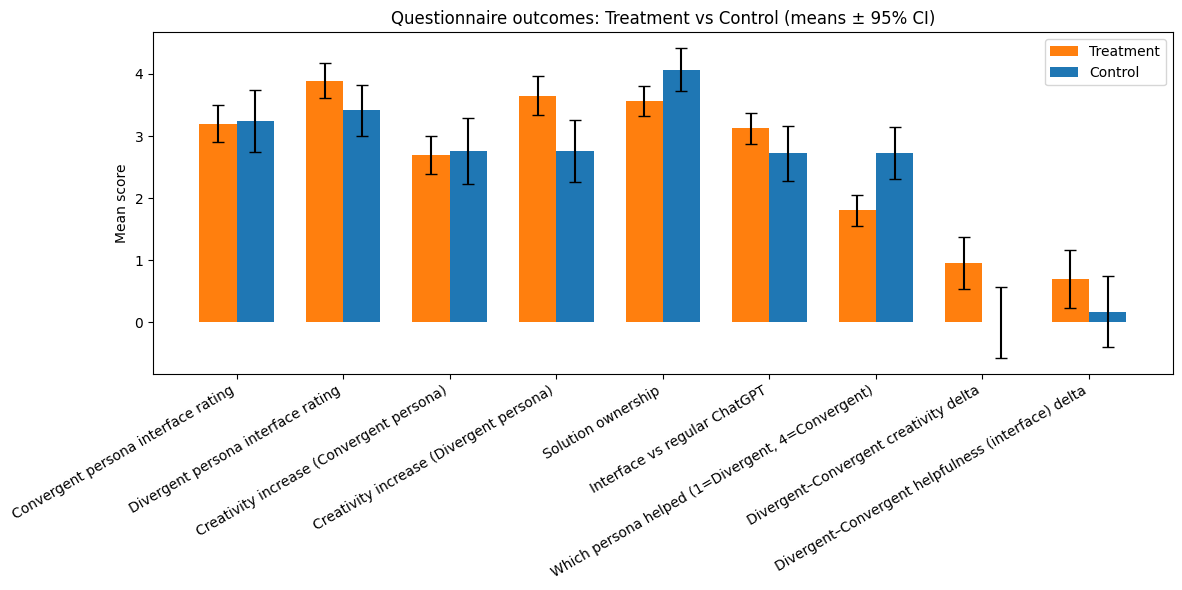

In [ ]:
# Google Colab-ready analysis cell
# --------------------------------------------------------------
# This cell:
# 1) Loads "Responses 13 07 (1).xlsx"
# 2) Computes Welch t-tests (Experiment vs Control) with Hedges' g
# 3) Reports means ± 95% CI
# 4) Adds Divergent–Convergent deltas
# 5) Plots a bar chart with 95% CIs (publication-ready)
# --------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display # Import the standard display function

# --------------------------
# Helper: robust file locate
# --------------------------
possible_paths = [
    "/content/Responses 13 07 (1).xlsx",         # typical Colab upload path
    "/mnt/data/Responses 13 07 (1).xlsx",        # project path (this environment)
    "Responses 13 07 (1).xlsx"                    # current working directory
]

xlsx_path = None
for p in possible_paths:
    if os.path.exists(p):
        xlsx_path = p
        break

# If not found in Colab, prompt user to upload (safe in Colab, harmless elsewhere)
if xlsx_path is None:
    try:
        from google.colab import files  # type: ignore
        print("Please upload: Responses 13 07 (1).xlsx")
        uploaded = files.upload()
        xlsx_path = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError("Could not find 'Responses 13 07 (1).xlsx'. Please upload it to Colab.") from e

# --------------------------
# Load & normalize dataset
# --------------------------
df = pd.read_excel(xlsx_path, sheet_name=0)
df.rename(columns={c: c.strip() for c in df.columns}, inplace=True)

# Detect group/condition column and normalize labels
def _normalize_group(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if "exp" in s or s == "1":
        return "Experiment"
    if "ctrl" in s or "control" in s or s == "0":
        return "Control"
    # fallback: return as-is if already nice
    return "Experiment" if val == "Experiment" else ("Control" if val == "Control" else np.nan)

group_col = None
for guess in ["Group type", "group", "Group", "condition", "Condition"]:
    if guess in df.columns:
        group_col = guess
        break
if group_col is None:
    # last resort: pick the first column that contains exp/ctrl tokens
    for c in df.select_dtypes(include="object").columns:
        vals = "|".join(map(str, df[c].dropna().unique())).lower()
        if any(tok in vals for tok in ["exp", "experiment"]) and any(tok in vals for tok in ["ctrl", "control"]):
            group_col = c
            break
if group_col is None:
    raise RuntimeError("Could not detect a 'group' column. Please ensure a column like 'Group type' exists.")

df["group_clean"] = df[group_col].apply(_normalize_group)

# Coerce relevant numeric columns (Alex = Convergent; Taylor = Divergent)
cols_numeric = [
    "alex_interface_rating",          # Convergent persona interface rating
    "taylor_interface_rating",        # Divergent persona interface rating
    "creativity_increase_alex",       # Creativity increase (Convergent)
    "creativity_increase_taylor",     # Creativity increase (Divergent)
    "solution_ownership",             # Solution ownership
    "interface_comparison",           # (optional/if present) interface vs regular ChatGPT
    "persona_helped"                  # Which persona helped (1=Divergent, 4=Convergent)
]
for c in cols_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Divergent–Convergent deltas
df["delta_creativity_div_minus_conv"] = df["creativity_increase_taylor"] - df["creativity_increase_alex"]
df["delta_helpfulness_div_minus_conv"] = df["taylor_interface_rating"] - df["alex_interface_rating"]

# --------------------------
# Stats helpers
# --------------------------
def mean_ci(x, alpha=0.05):
    x = pd.Series(x).dropna()
    n = x.shape[0]
    if n == 0:
        return np.nan, np.nan, np.nan, n
    m = x.mean()
    sd = x.std(ddof=1)
    se = sd / math.sqrt(n) if n > 0 else np.nan
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1) if n > 1 else np.nan
    half = tcrit * se if n > 1 else np.nan
    return m, m - half, m + half, n

def welch_test_and_hedges_g(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan
    res = stats.ttest_ind(a, b, equal_var=False)
    # Hedges' g with small-sample correction
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2)) if (n1+n2-2) > 0 else np.nan
    g = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    J = 1 - (3 / (4*(n1+n2) - 9)) if (n1+n2) > 2 else 1.0
    g *= J
    return float(res.pvalue), float(g), float(res.statistic)

# --------------------------
# Define metrics to analyze
# --------------------------
metrics = {
    # Rename for paper: Convergent/Divergent persona
    "Convergent persona interface rating": "alex_interface_rating",
    "Divergent persona interface rating": "taylor_interface_rating",
    "Creativity increase (Convergent persona)": "creativity_increase_alex",
    "Creativity increase (Divergent persona)": "creativity_increase_taylor",
    "Solution ownership": "solution_ownership",
    "Interface vs regular ChatGPT": "interface_comparison",  # may be NaN or absent
    "Which persona helped (1=Divergent, 4=Convergent)": "persona_helped",
    "Divergent–Convergent creativity delta": "delta_creativity_div_minus_conv",
    "Divergent–Convergent helpfulness (interface) delta": "delta_helpfulness_div_minus_conv",
}

# --------------------------
# Compute group stats
# --------------------------
rows = []
for label, col in metrics.items():
    if col not in df.columns:
        # Allow missing optional fields (e.g., interface_comparison)
        exp_m = exp_lo = exp_hi = exp_sd = ctrl_m = ctrl_lo = ctrl_hi = ctrl_sd = np.nan
        pval = g = np.nan
        n_exp = n_ctrl = 0
    else:
        exp_vals = df.loc[df["group_clean"] == "Experiment", col]
        ctrl_vals = df.loc[df["group_clean"] == "Control", col]

        exp_m, exp_lo, exp_hi, n_exp = mean_ci(exp_vals)
        ctrl_m, ctrl_lo, ctrl_hi, n_ctrl = mean_ci(ctrl_vals)

        exp_sd = exp_vals.std(ddof=1) if n_exp > 1 else np.nan
        ctrl_sd = ctrl_vals.std(ddof=1) if n_ctrl > 1 else np.nan

        pval, hedges_g, _ = welch_test_and_hedges_g(exp_vals, ctrl_vals)
        g = hedges_g

    rows.append({
        "metric": label,
        "n_exp": n_exp, "exp_mean": exp_m, "exp_sd": exp_sd, "exp_ci_lo": exp_lo, "exp_ci_hi": exp_hi,
        "n_ctrl": n_ctrl, "ctrl_mean": ctrl_m, "ctrl_sd": ctrl_sd, "ctrl_ci_lo": ctrl_lo, "ctrl_ci_hi": ctrl_hi,
        "Δ (Exp − Ctrl)": (exp_m - ctrl_m) if (pd.notna(exp_m) and pd.notna(ctrl_m)) else np.nan,
        "Hedges g": g,
        "Welch p": pval,
    })

results = pd.DataFrame(rows)

# Order for display (logical grouping)
display_order = [
    "Convergent persona interface rating",
    "Divergent persona interface rating",
    "Creativity increase (Convergent persona)",
    "Creativity increase (Divergent persona)",
    "Solution ownership",
    "Interface vs regular ChatGPT",
    "Which persona helped (1=Divergent, 4=Convergent)",
    "Divergent–Convergent creativity delta",
    "Divergent–Convergent helpfulness (interface) delta",
]
results["order"] = results["metric"].apply(lambda m: display_order.index(m) if m in display_order else 999)
results = results.sort_values("order").drop(columns=["order"])

# Pretty copy
display_tbl = results.copy()
for c in ["exp_mean","exp_sd","exp_ci_lo","exp_ci_hi","ctrl_mean","ctrl_sd","ctrl_ci_lo","ctrl_ci_hi","Δ (Exp − Ctrl)","Hedges g","Welch p"]:
    display_tbl[c] = display_tbl[c].astype(float).round(5)

# Show to the user as a table
# Removed import from caas_jupyter_tools and used standard display
display(display_tbl)

# --------------------------
# Plot (means ± 95% CI)
# --------------------------
labels = display_order
exp_means = [results.loc[results["metric"]==lab, "exp_mean"].values[0] for lab in labels]
exp_errs = [results.loc[results["metric"]==lab, "exp_ci_hi"].values[0] - results.loc[results["metric"]==lab, "exp_mean"].values[0] for lab in labels]
ctrl_means = [results.loc[results["metric"]==lab, "ctrl_mean"].values[0] for lab in labels]
ctrl_errs = [results.loc[results["metric"]==lab, "ctrl_ci_hi"].values[0] - results.loc[results["metric"]==lab, "ctrl_mean"].values[0] for lab in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, exp_means, width, yerr=exp_errs, capsize=4, label="Treatment", color="tab:orange")
plt.bar(x + width/2, ctrl_means, width, yerr=ctrl_errs, capsize=4, label="Control", color="tab:blue")
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel("Mean score")
plt.title("Questionnaire outcomes: Treatment vs Control (means ± 95% CI)")
plt.legend()
plt.tight_layout()

fig_path = "/content/questionnaire_exp_vs_ctrl_divergent_convergent.png"
plt.savefig(fig_path, dpi=300)
print("Figure saved to:", fig_path)

# Persona-helped analysis

N by group:
group
Treatment    66
Control      29 

Proportions by group (persona_helped = 1..4):
persona_helped      1      2      3      4
group                                     
Treatment       0.515  0.273  0.106  0.106
Control         0.172  0.241  0.276  0.310 

Mean (1=Taylor .. 4=Alex) by group:
group
Treatment    1.80
Control      2.72 

Figure saved to: /content/persona_helped_experiment_vs_control.png


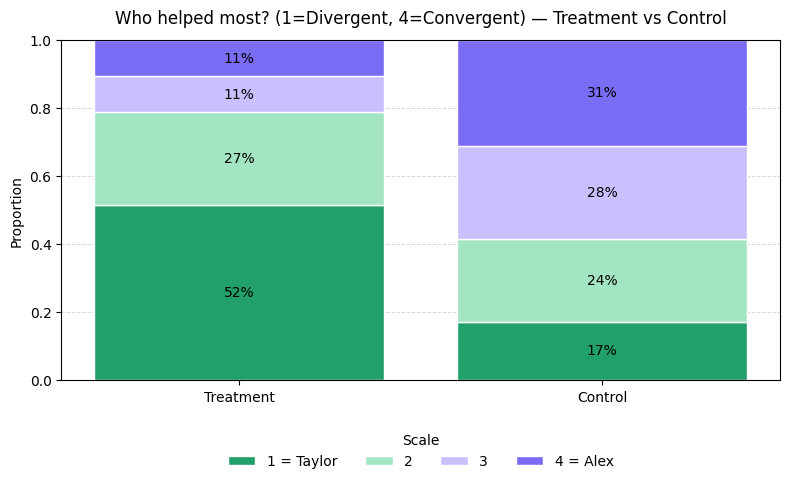

In [ ]:
# --- Persona-helped analysis & figure (Colab cell) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===== 1) Load data =====
# Point to your file; if not found, you'll be prompted to upload it.
filepath_candidates = [
    "/content/Responses 13 07 (1) (1).xlsx",          # common Colab path if you uploaded to /content
    "/content/Responses 13 07 (1).xlsx",              # alt name
    "/content/Responses_13_07.xlsx",                  # alt name
    "Responses 13 07 (1).xlsx"                    # current working dir
]

xls = None
for p in filepath_candidates:
    if Path(p).exists():
        xls = pd.ExcelFile(p)
        filepath = p
        break

if xls is None:
    try:
        from google.colab import files  # type: ignore
        print("Upload the Excel file with the questionnaire responses…")
        uploaded = files.upload()
        filepath = list(uploaded.keys())[0]
        xls = pd.ExcelFile(filepath)
    except Exception as e:
        raise FileNotFoundError(
            "Could not find the Excel file. Upload it or update 'filepath_candidates'."
        )

# Prefer a known sheet name if present; else use the first sheet
sheet_name = "responses1307" if "responses1307" in xls.sheet_names else xls.sheet_names[0]
df = pd.read_excel(filepath, sheet_name=sheet_name)

# ===== 2) Clean & compute results =====
# Keep valid 1–4 responses
df = df[df["persona_helped"].isin([1, 2, 3, 4])].copy()

# Normalize group labels and order EXPERIMENT (left) then CONTROL (right)
df["group"] = df["Group type"].map({
    "Experiment Group": "Treatment", # Changed from Experiment
    "Control Group": "Control"
}).fillna(df["Group type"])

groups = ["Treatment", "Control"] # Changed from Experiment

# Crosstab: counts and proportions by group × persona_helped
counts = pd.crosstab(df["group"], df["persona_helped"]).reindex(index=groups, columns=[1,2,3,4]).fillna(0).astype(int)
props  = counts.div(counts.sum(axis=1), axis=0)

# Group means (for reporting)
means = df.groupby("group")["persona_helped"].mean().reindex(groups)

print("N by group:")
print(counts.sum(axis=1).to_string(), "\n")
print("Proportions by group (persona_helped = 1..4):")
print(props.round(3).to_string(), "\n")
print("Mean (1=Taylor .. 4=Alex) by group:")
print(means.round(2).to_string(), "\n")

# ===== 3) Figure =====
# Interface-inspired palette:
# Taylor (divergent): greens; Alex (convergent): purples
palette = {
    1: "#22A06B",  # 1 = Taylor (deep green)
    2: "#A3E4C2",  # 2 = lighter green
    3: "#C8C0FF",  # 3 = light purple
    4: "#7A6CF5",  # 4 = Alex (deep purple)
}
labels = {1: "1 = Taylor", 2: "2", 3: "3", 4: "4 = Alex"}

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(groups))
for k in [1, 2, 3, 4]:
    vals = props.loc[groups, k].values
    ax.bar(groups, vals, bottom=bottom,
           color=palette[k], edgecolor="white", linewidth=1.0, label=labels[k])
    bottom += vals

# Styling
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")
ax.set_title("Who helped most? (1=Divergent, 4=Convergent) — Treatment vs Control", pad=12) # Changed from Experiment
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)
ax.set_axisbelow(True)

# Add % labels where large enough to read
for i, g in enumerate(groups):
    cum = 0
    for k in [1, 2, 3, 4]:
        v = props.loc[g, k]
        if v >= 0.09:  # only annotate sizeable slices
            ax.text(i, cum + v/2, f"{int(round(v*100))}%",
                    ha="center", va="center", fontsize=10)
        cum += v

# Legend below the plot
ax.legend(ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.12), loc="upper center", title="Scale")
plt.tight_layout()

# Save and show
out_path = "/content/persona_helped_experiment_vs_control.png" # Filename remains the same
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {out_path}")

plt.show()

# Traits anaylsis

Significant correlations (Treatment-only; Control non-significant in these cells):


,Trait,Outcome,r (Treatment),95% CI lo (Treatment),95% CI hi (Treatment),p (Treatment),n (Treatment),r (Control),p (Control),n (Control)
5,Agreeableness,Interface vs regular ChatGPT,0.490,0.281,0.655,0.000,66,0.107,0.580,29
3,Agreeableness,Creativity increase (Divergent persona),0.404,0.179,0.588,0.001,66,0.124,0.521,29
1,Agreeableness,Divergent persona interface rating,0.272,0.032,0.482,0.027,66,0.275,0.148,29
37,Openness,Interface vs regular ChatGPT,0.367,0.137,0.559,0.002,66,-0.338,0.073,29
36,Openness,Solution ownership,0.283,0.044,0.492,0.021,66,0.131,0.500,29
8,Extraversion,Convergent persona interface rating,0.260,0.019,0.472,0.035,66,0.021,0.916,29


Saved figure to: figure_10a_significant_correlations_sorted.png


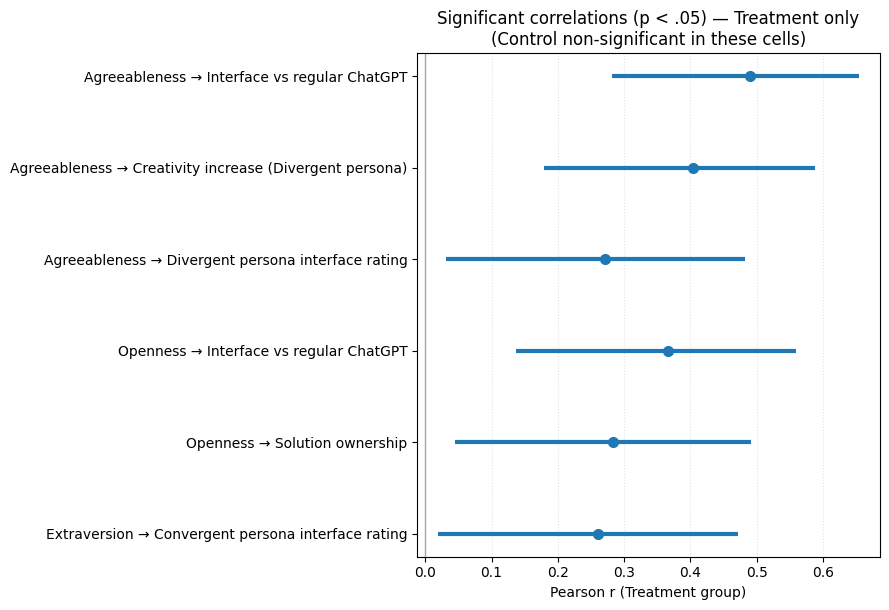

In [ ]:
# === Figure 10a — Significant correlations (Treatment only) from "Responses 13 07 (1).xlsx" ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# ---------- 1) Load ----------
FILE = "Responses 13 07 (1).xlsx"
df = pd.read_excel(FILE, sheet_name=0)
df.rename(columns={c: c.strip() for c in df.columns}, inplace=True)

# Normalize group labels
def _norm_group(x):
    s = str(x).lower()
    if "experiment" in s:
        return "Experiment"
    if "control" in s:
        return "Control"
    return np.nan

df["group_clean"] = df["Group type"].apply(_norm_group)

# ---------- 2) Identify trait & outcome columns ----------
def _first_present(opts):
    for o in opts:
        if o in df.columns:
            return o
    return None

# IMPORTANT:
# Use "Openness" as the display label, even if the raw column in the file is named Open-Mindedness
trait_col_map = {
    "Agreeableness": _first_present(["Agreeableness", "agreeableness"]),
    "Extraversion": _first_present(["Extraversion", "extraversion"]),
    "Conscientiousness": _first_present(["Conscientiousness", "conscientiousness"]),
    "Negative Emotionality": _first_present(
        ["Negative Emotionality", "Neuroticism", "neuroticism", "negative_emotionality"]
    ),
    "Openness": _first_present(["Openness", "Open-Mindedness", "openness"]),
}

missing = [t for t, c in trait_col_map.items() if c is None]
if missing:
    raise ValueError(
        f"Could not find trait columns for: {missing}. "
        "Please verify that continuous Big Five trait scores are present in the sheet."
    )

q_map = {
    "alex_interface_rating": "Convergent persona interface rating",
    "taylor_interface_rating": "Divergent persona interface rating",
    "creativity_increase_alex": "Creativity increase (Convergent persona)",
    "creativity_increase_taylor": "Creativity increase (Divergent persona)",
    "solution_ownership": "Solution ownership",
    "interface_comparison": "Interface vs regular ChatGPT",
    "persona_helped": "Which persona helped (1=Divergent, 4=Convergent)",
    "ai_tool_mastery": "AI tool proficiency",
}

outcome_cols = [c for c in q_map.keys() if c in df.columns]
if not outcome_cols:
    raise ValueError("No questionnaire outcome columns were found. Check the column names in the workbook.")

for c in outcome_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------- 3) Pearson correlations by group ----------
def pearson_by_group(data, trait_col, outcome_col, group):
    sub = data.loc[data["group_clean"] == group, [trait_col, outcome_col]].dropna()
    if len(sub) < 4:
        return np.nan, np.nan, len(sub)
    r, p = stats.pearsonr(sub[trait_col], sub[outcome_col])
    return r, p, len(sub)

rows = []
for trait_label, trait_col in trait_col_map.items():
    for outcome_col in outcome_cols:
        r_exp, p_exp, n_exp = pearson_by_group(df, trait_col, outcome_col, "Experiment")
        r_ctrl, p_ctrl, n_ctrl = pearson_by_group(df, trait_col, outcome_col, "Control")
        rows.append({
            "Trait": trait_label,
            "Outcome_code": outcome_col,
            "Outcome": q_map[outcome_col],
            "r_exp": r_exp,
            "p_exp": p_exp,
            "n_exp": n_exp,
            "r_ctrl": r_ctrl,
            "p_ctrl": p_ctrl,
            "n_ctrl": n_ctrl,
        })

res = pd.DataFrame(rows)

# ---------- 4) Keep only Experiment-significant & Control-non-significant ----------
sig = res[(res["p_exp"] < 0.05) & ((res["p_ctrl"].isna()) | (res["p_ctrl"] >= 0.05))].copy()

if sig.empty:
    print("No Treatment-only significant correlations (with Control non-significant) were found.")
else:
    # ---------- 5) Fisher z CI for r ----------
    def fisher_ci(r, n, alpha=0.05):
        if np.isnan(r) or n is None or n <= 3:
            return (np.nan, np.nan)
        z = np.arctanh(r)
        se = 1.0 / np.sqrt(n - 3)
        zcrit = stats.norm.ppf(1 - alpha / 2)
        return (np.tanh(z - zcrit * se), np.tanh(z + zcrit * se))

    sig["ci_lo"], sig["ci_hi"] = zip(*sig.apply(lambda r: fisher_ci(r["r_exp"], r["n_exp"]), axis=1))

    # ---------- 6) Logical sorting ----------
    # Adjust this order to match the order you describe in the text
    trait_order = [
        "Agreeableness",
        "Openness",
        "Extraversion",
        "Conscientiousness",
        "Negative Emotionality",
    ]

    # Adjust within-trait outcome order to match text order
    outcome_order = [
        "Interface vs regular ChatGPT",
        "Creativity increase (Divergent persona)",
        "Divergent persona interface rating",
        "Solution ownership",
        "Convergent persona interface rating",
        "Creativity increase (Convergent persona)",
        "Which persona helped (1=Divergent, 4=Convergent)",
        "AI tool proficiency",
    ]

    sig["trait_sort"] = pd.Categorical(sig["Trait"], categories=trait_order, ordered=True)
    sig["outcome_sort"] = pd.Categorical(sig["Outcome"], categories=outcome_order, ordered=True)

    sig = sig.sort_values(["trait_sort", "outcome_sort"])

    sig["Label"] = sig["Trait"] + " \u2192 " + sig["Outcome"]

    # ---------- Table for the paper ----------
    table = sig[
        ["Trait", "Outcome", "r_exp", "ci_lo", "ci_hi", "p_exp", "n_exp", "r_ctrl", "p_ctrl", "n_ctrl"]
    ].rename(
        columns={
            "r_exp": "r (Treatment)",
            "ci_lo": "95% CI lo (Treatment)",
            "ci_hi": "95% CI hi (Treatment)",
            "p_exp": "p (Treatment)",
            "n_exp": "n (Treatment)",
            "r_ctrl": "r (Control)",
            "p_ctrl": "p (Control)",
            "n_ctrl": "n (Control)",
        }
    )

    print("Significant correlations (Treatment-only; Control non-significant in these cells):")
    display(table.round(3))

    # ---------- 7) Plot ----------
    plt.figure(figsize=(9, max(4.5, 0.7 * len(sig) + 2)))
    y = np.arange(len(sig))

    plt.hlines(y, sig["ci_lo"], sig["ci_hi"], linewidth=3)
    plt.plot(sig["r_exp"], y, "o", markersize=7)

    plt.axvline(0, color="0.65", linewidth=1)

    plt.yticks(y, sig["Label"])
    plt.gca().invert_yaxis()  # first row appears at top
    plt.xlabel("Pearson r (Treatment group)")
    plt.title("Significant correlations (p < .05) — Treatment only\n(Control non-significant in these cells)")
    plt.grid(axis="x", linestyle=":", alpha=0.35)
    plt.tight_layout()

    out_png = "figure_10a_significant_correlations_sorted.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {out_png}")
    plt.show()

# Conversation dynamic

## Version 1


In [ ]:
# --- Validation notebook (Excel-based): User–Persona streaks (Q2–Q4), traits, and ending preference ---

# 0) Setup
!pip -q install pandas scipy statsmodels openpyxl

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import glob, os, re, math, warnings

warnings.filterwarnings("ignore")

# 1) Locate and load the two Excel files (already present in the Colab working dir)
def pick_one(pattern):
    hits = sorted(glob.glob(pattern))
    if not hits:
        raise FileNotFoundError(f"No files matched: {pattern}")
    # prefer a "(2).xlsx" copy if both exist
    hits_sorted = sorted(hits, key=lambda p: ("(2)" not in p, p))
    return hits_sorted[0]

MSGS_PATH   = pick_one("*messages1307_quartered*.xlsx")
TRAITS_PATH = pick_one("*Responses 13 07*.xlsx")

MSGS_SHEET   = "messages1307_quartered"
TRAITS_SHEET = "responses1307"

msgs   = pd.read_excel(MSGS_PATH, sheet_name=MSGS_SHEET)
traits = pd.read_excel(TRAITS_PATH, sheet_name=TRAITS_SHEET)

# Basic cleanup
msgs.columns   = [c.strip() for c in msgs.columns]
traits.columns = [c.strip() for c in traits.columns]

# 2) Keep only Q2–Q4 (post-familiarization)
# Ensure sort columns exist; fall back sensibly if needed
if "pos" not in msgs.columns:
    # try to derive a position by timestamp or row order
    if "timestamp" in msgs.columns:
        msgs = msgs.sort_values(["conversation_id", "timestamp"]).copy()
    else:
        msgs = msgs.sort_values(["conversation_id"]).copy()
    msgs["pos"] = msgs.groupby("conversation_id").cumcount() + 1
else:
    msgs = msgs.sort_values(["conversation_id", "pos"]).copy()

if "quarter" not in msgs.columns:
    raise KeyError("Expected a 'quarter' column (Q1..Q4) in messages sheet.")

msgs = msgs.reset_index(drop=True)
msgs_q234 = msgs[msgs["quarter"].isin(["Q2", "Q3", "Q4"])].copy()

# 3) Infer the target persona for each USER message by peeking at the next assistant message
SPEAKER_COL = "message source" if "message source" in msgs_q234.columns else \
              ("message_src" if "message_src" in msgs_q234.columns else None)
if SPEAKER_COL is None:
    raise KeyError("Could not find a speaker column like 'message source' or 'message_src'")

def assign_targets(df_one_conv: pd.DataFrame) -> pd.DataFrame:
    df = df_one_conv.copy().reset_index(drop=True)
    target = [None] * len(df)
    for i in range(len(df) - 1):
        if str(df.loc[i, SPEAKER_COL]).lower() == "user":
            j = i + 1
            # find next assistant (Alex/Taylor)
            while j < len(df) and str(df.loc[j, SPEAKER_COL]).lower() == "user":
                j += 1
            if j < len(df):
                who = str(df.loc[j, SPEAKER_COL])
                if who in ("Alex", "Taylor"):
                    target[i] = "Convergent" if who == "Alex" else "Divergent"
    df["target_persona"] = target
    return df

msgs_q234 = msgs_q234.groupby("conversation_id", group_keys=False).apply(assign_targets)

# 4) Build user-only stream with known target
user_msgs = msgs_q234[(msgs_q234[SPEAKER_COL].astype(str).str.lower() == "user") &
                      (msgs_q234["target_persona"].notna())].copy()

# 5) Compute streaks + per-conversation metrics
def compute_streaks(df_user_one_conv: pd.DataFrame):
    df = df_user_one_conv.sort_values("pos").copy()
    df["switch"]    = (df["target_persona"] != df["target_persona"].shift(1)).astype(int)
    df["streak_id"] = df["switch"].cumsum()

    # streak length per streak_id
    streak_len = df.groupby("streak_id").size().rename("streak_len")
    df = df.join(streak_len, on="streak_id")

    last_target = df["target_persona"].iloc[-1] if len(df) else np.nan
    switches    = max(df["switch"].sum() - 1, 0) if len(df) else 0
    return df, last_target, switches

streak_rows   = []
end_persona   = {}
switch_counts = {}

for cid, dfc in user_msgs.groupby("conversation_id"):
    dff, last, sw = compute_streaks(dfc)
    streak_rows.append(dff.assign(conversation_id=cid))
    end_persona[cid]   = last
    switch_counts[cid] = sw

streaks = pd.concat(streak_rows, ignore_index=True) if len(streak_rows) else pd.DataFrame()

# Aggregate per conversation × persona
count_col = "message_id" if "message_id" in streaks.columns else None
if count_col is None:
    # fall back to counting rows
    streaks["__row__"] = 1
    count_col = "__row__"

per_conv = (
    streaks.groupby(["conversation_id", "target_persona"])
           .agg(user_msgs=(count_col, "count"),
                mean_streak=("streak_len", "mean"))
           .reset_index()
)

wide = per_conv.pivot(index="conversation_id",
                      columns="target_persona",
                      values=["user_msgs", "mean_streak"]).fillna(0)
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index()
wide["switches"]    = wide["conversation_id"].map(switch_counts).fillna(0).astype(int)
wide["end_persona"] = wide["conversation_id"].map(end_persona)

# 6) Merge traits + groups (Excel sheet columns)
def norm_group(s):
    s = str(s).lower()
    if "exp" in s:   return "Experiment"
    if "ctrl" in s:  return "Control"
    if "experiment" in s: return "Experiment"
    if "control" in s:    return "Control"
    return s.title()

# Map the inventory names used in your Excel to canonical Big5 labels
# 'Negative Emotionality' -> Neuroticism ; 'Open-Mindedness' -> Openness
trait_name_map = {
    "Extraversion": "Extraversion",
    "Agreeableness": "Agreeableness",
    "Conscientiousness": "Conscientiousness",
    "Negative Emotionality": "Neuroticism",
    "Open-Mindedness": "Openness",
}

required_traits_present = [raw for raw in trait_name_map.keys() if raw in traits.columns]
if len(required_traits_present) < 4:
    raise KeyError(f"Expected at least 4 Big5 columns; found {required_traits_present}")

group_col = "Group type" if "Group type" in traits.columns else \
            ("group typer" if "group typer" in traits.columns else None)
if group_col is None:
    # try common alternatives
    for alt in ["Group", "group", "condition", "Condition"]:
        if alt in traits.columns:
            group_col = alt
            break
if group_col is None:
    raise KeyError("Could not find a 'Group type' column in the responses sheet.")

traits_small = traits[["conversation_id", group_col] + required_traits_present].copy()
traits_small["group_clean"] = traits_small[group_col].apply(norm_group)

# Canonicalize to: Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness
for raw, std in trait_name_map.items():
    if raw in traits_small.columns:
        traits_small[std] = pd.to_numeric(traits_small[raw], errors="coerce")

keep_cols = ["conversation_id", "group_clean", "Extraversion", "Agreeableness",
             "Conscientiousness", "Neuroticism", "Openness"]
traits_small = traits_small[[c for c in keep_cols if c in traits_small.columns]].copy()

data = wide.merge(traits_small, on="conversation_id", how="left")

# 7) Helpers for stats
def welch_t(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan, len(a), len(b)
    t = stats.ttest_ind(a, b, equal_var=False)
    # Hedges g
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2)) if (n1+n2-2) > 0 else np.nan
    g  = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    J  = 1 - (3 / (4*(n1+n2) - 9)) if (n1+n2) > 2 else 1.0
    return t.statistic, t.pvalue, g*J, n1, n2

def mean_ci(x, alpha=0.05):
    x = pd.to_numeric(x, errors="coerce").dropna()
    n = len(x)
    if n < 2: return (np.nan, np.nan, np.nan, n)
    m  = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    return (m, m - tcrit*se, m + tcrit*se, n)

# 8) RQ1 — Group differences (Welch t) on Q2–Q4 per-conversation metrics
metrics = ["user_msgs_Divergent", "user_msgs_Convergent",
           "mean_streak_Divergent", "mean_streak_Convergent", "switches"]

rows = []
for m in metrics:
    exp = data.loc[data["group_clean"]=="Experiment", m]
    ctrl= data.loc[data["group_clean"]=="Control",    m]
    mE, loE, hiE, nE = mean_ci(exp)
    mC, loC, hiC, nC = mean_ci(ctrl)
    tval, pval, g, n1, n2 = welch_t(exp, ctrl)
    rows.append(dict(metric=m,
                     exp_mean=mE, exp_ci_lo=loE, exp_ci_hi=hiE, n_exp=nE,
                     ctrl_mean=mC, ctrl_ci_lo=loC, ctrl_ci_hi=hiC, n_ctrl=nC,
                     welch_t=tval, welch_p=pval, hedges_g=g))
grp_results = pd.DataFrame(rows)

print("\n=== RQ1: Experiment vs Control (Welch t) on Q2–Q4 metrics ===")
print(grp_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 9) RQ2 — Trait correlations with messaging (Pearson r), by group
trait_cols_all = [c for c in ["Extraversion","Agreeableness","Conscientiousness","Neuroticism","Openness"] if c in data.columns]

def corr_table(df):
    out=[]
    for t in trait_cols_all:
        for m in metrics:
            if m not in df.columns:
                continue
            x = df[t]; y = df[m]
            mask = x.notna() & y.notna()
            if mask.sum() >= 3:
                r, p = stats.pearsonr(x[mask], y[mask])
                out.append(dict(trait=t, metric=m, r=r, p=p, n=int(mask.sum())))
    return pd.DataFrame(out)

corr_exp  = corr_table(data[data["group_clean"]=="Experiment"])
corr_ctrl = corr_table(data[data["group_clean"]=="Control"])

sig_exp   = corr_exp[corr_exp["p"] < 0.05].sort_values(["trait","metric"])
sig_ctrl  = corr_ctrl[corr_ctrl["p"] < 0.05].sort_values(["trait","metric"])

print("\n=== RQ2: Significant Pearson correlations (Experiment only) ===")
if len(sig_exp):
    print(sig_exp.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("None at p<.05")

# Helpful note about the specific claim in your writeup:
# Check that the two Conscientiousness↔Convergent relationships are *not* significant in Control.
ctrl_consc = corr_ctrl[(corr_ctrl["trait"]=="Conscientiousness") &
                       (corr_ctrl["metric"].isin(["user_msgs_Convergent","mean_streak_Convergent"]))]
if len(ctrl_consc):
    print("\nControl (Conscientiousness ↔ Convergent metrics):")
    print(ctrl_consc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n(For completeness) Control significant correlations (if any):")
print(sig_ctrl.to_string(index=False, float_format=lambda x: f"{x:.3f}")) if len(sig_ctrl) else print("None at p<.05")

# 10) RQ3 — Trait extremes (Q1 vs Q4) and ending persona (Divergent vs Convergent)

def extremes_pref_quantile(df_group, trait_name):
    # Inclusive quantiles (<= Q1 vs >= Q3) – captures ties at the cutpoints
    sub = df_group[[trait_name, "end_persona"]].dropna()
    if sub.empty:
        return None
    q1 = sub[trait_name].quantile(0.25)
    q3 = sub[trait_name].quantile(0.75)
    low  = sub[sub[trait_name] <= q1]
    high = sub[sub[trait_name] >= q3]
    def counts(s):
        dv = (s["end_persona"]=="Divergent").sum()
        cv = (s["end_persona"]=="Convergent").sum()
        return dv, cv
    dv_high, cv_high = counts(high)
    dv_low,  cv_low  = counts(low)
    table = np.array([[dv_high, cv_high],[dv_low, cv_low]], dtype=int)
    if table.size == 0 or min(table.sum(axis=1)) == 0 or min(table.sum(axis=0)) == 0:
        return None
    if (table < 5).any():
        odds_ratio, p = stats.fisher_exact(table)
        test_name = "Fisher"
        stat = odds_ratio
    else:
        chi2, p, dof, _ = stats.chi2_contingency(table)
        test_name = "Chi2"
        stat = chi2
    return dict(trait=trait_name,
                n_high=len(high), n_low=len(low),
                high_divergent=dv_high, high_convergent=cv_high,
                low_divergent=dv_low,   low_convergent=cv_low,
                test=test_name, stat=stat, p=p)

def extremes_pref_rank(df_group, trait_name):
    # Rank-based 25% tails (avoids tie inflation; often closer to equal-n tails)
    sub = df_group[[trait_name, "end_persona"]].dropna().sort_values(trait_name)
    n = len(sub)
    if n < 4:
        return None
    k = max(int(np.floor(n * 0.25)), 1)
    low  = sub.iloc[:k]
    high = sub.iloc[-k:]
    def counts(s):
        dv = (s["end_persona"]=="Divergent").sum()
        cv = (s["end_persona"]=="Convergent").sum()
        return dv, cv
    dv_high, cv_high = counts(high)
    dv_low,  cv_low  = counts(low)
    table = np.array([[dv_high, cv_high],[dv_low, cv_low]], dtype=int)
    if (table < 5).any():
        odds_ratio, p = stats.fisher_exact(table)
        test_name = "Fisher"
        stat = odds_ratio
    else:
        chi2, p, dof, _ = stats.chi2_contingency(table)
        test_name = "Chi2"
        stat = chi2
    return dict(trait=trait_name,
                n_high=len(high), n_low=len(low),
                high_divergent=dv_high, high_convergent=cv_high,
                low_divergent=dv_low,   low_convergent=cv_low,
                test=test_name, stat=stat, p=p)

def run_pref(df, group_label, method="rank"):
    sub = df[df["group_clean"]==group_label].copy()
    out = []
    for t in trait_cols_all:
        res = extremes_pref_rank(sub, t) if method=="rank" else extremes_pref_quantile(sub, t)
        if res is not None:
            res["group"] = group_label
            res["method"] = method
            out.append(res)
    return pd.DataFrame(out)

# Run both methods so you can compare (rank-based is often closer to your reported sample splits)
pref_exp_rank  = run_pref(data, "Experiment", method="rank")
pref_ctrl_rank = run_pref(data, "Control",    method="rank")
pref_exp_qinc  = run_pref(data, "Experiment", method="quantile")
pref_ctrl_qinc = run_pref(data, "Control",    method="quantile")

print("\n=== RQ3: Trait extremes vs ending persona (Experiment, rank-based 25% tails) ===")
print(pref_exp_rank.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nSignificant (p<.05):")
print(pref_exp_rank[pref_exp_rank["p"]<0.05].to_string(index=False, float_format=lambda x: f"{x:.3f}")) \
    if (pref_exp_rank["p"]<0.05).any() else print("None")

print("\n=== Control (rank-based 25% tails) ===")
print(pref_ctrl_rank.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nControl significant (p<.05):")
print(pref_ctrl_rank[pref_ctrl_rank["p"]<0.05].to_string(index=False, float_format=lambda x: f"{x:.3f}")) \
    if (pref_ctrl_rank["p"]<0.05).any() else print("None")

# Optional: also display the inclusive-quantile method to compare with any prior drafts
print("\n--- (Optional) Inclusive-quantile method (<=Q1 vs >=Q3) ---")
print("(Experiment)")
print(pref_exp_qinc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\n(Control)")
print(pref_ctrl_qinc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Continuous check: Extraversion ↔ ending with Divergent (Experiment)
if "Extraversion" in data.columns:
    exp_sub = data[data["group_clean"]=="Experiment"].copy()
    end_div = (exp_sub["end_persona"]=="Divergent").astype(float)
    mask = exp_sub["Extraversion"].notna() & end_div.notna()
    if mask.sum() >= 3:
        r, p = stats.pearsonr(exp_sub.loc[mask, "Extraversion"], end_div[mask])
        print(f"\nContinuous check (Experiment): Extraversion vs end_with_Divergent (1/0): r={r:.3f}, p={p:.3g}, n={mask.sum()}")

# 11) Save CSV outputs for the paper supplement (matches your original filenames)
corr_exp.to_csv("validation_correlations_experiment.csv", index=False)
corr_ctrl.to_csv("validation_correlations_control.csv", index=False)
grp_results.to_csv("validation_group_differences_q2q4.csv", index=False)

# Save both extremes methods so you can pick the one that aligns with your reporting
pref_exp_rank.to_csv("validation_preference_extremes_experiment_rank.csv", index=False)
pref_ctrl_rank.to_csv("validation_preference_extremes_control_rank.csv", index=False)
pref_exp_qinc.to_csv("validation_preference_extremes_experiment_qinclusive.csv", index=False)
pref_ctrl_qinc.to_csv("validation_preference_extremes_control_qinclusive.csv", index=False)

print("\nSaved CSVs:\n- validation_group_differences_q2q4.csv"
      "\n- validation_correlations_experiment.csv"
      "\n- validation_correlations_control.csv"
      "\n- validation_preference_extremes_experiment_rank.csv"
      "\n- validation_preference_extremes_control_rank.csv"
      "\n- validation_preference_extremes_experiment_qinclusive.csv"
      "\n- validation_preference_extremes_control_qinclusive.csv")



=== RQ1: Experiment vs Control (Welch t) on Q2–Q4 metrics ===
                metric  exp_mean  exp_ci_lo  exp_ci_hi  n_exp  ctrl_mean  ctrl_ci_lo  ctrl_ci_hi  n_ctrl  welch_t  welch_p  hedges_g
   user_msgs_Divergent     6.108      4.955      7.260     65      5.690       3.985       7.394      29    0.413    0.681     0.090
  user_msgs_Convergent     5.277      4.205      6.349     65      6.448       3.511       9.385      29   -0.765    0.449    -0.208
 mean_streak_Divergent     4.011      2.977      5.045     65      3.575       2.340       4.809      29    0.549    0.584     0.111
mean_streak_Convergent     3.306      2.414      4.197     65      4.817       1.812       7.822      29   -0.985    0.332    -0.283
              switches     3.092      2.289      3.896     65      2.862       1.631       4.093      29    0.318    0.751     0.070

=== RQ2: Significant Pearson correlations (Experiment only) ===
            trait                 metric     r     p  n
Conscientiousness 

## Version 2

In [ ]:
# --- Validation notebook (Excel-based): User–Persona streaks (Q2–Q4), traits, and ending preference ---

# 0) Setup
!pip -q install pandas scipy statsmodels openpyxl

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import glob, os, re, math, warnings

warnings.filterwarnings("ignore")

# 1) Locate and load the two Excel files (already present in the Colab working dir)
#    Deterministic: pick the most recently modified match; tie-break by highest numeric suffix like "(4).xlsx".
def _suffix_num(path: str) -> int:
    m = re.search(r"\((\d+)\)\.xlsx$", os.path.basename(path))
    return int(m.group(1)) if m else -1

def pick_latest(pattern: str) -> str:
    hits = glob.glob(pattern)
    if not hits:
        raise FileNotFoundError(f"No files matched: {pattern}")
    hits.sort(key=lambda p: (os.path.getmtime(p), _suffix_num(p)))
    return hits[-1]

MSGS_PATH   = pick_latest("*messages1307_quartered*.xlsx")
TRAITS_PATH = pick_latest("*Responses 13 07*.xlsx")

MSGS_SHEET   = "messages1307_quartered"
TRAITS_SHEET = "responses1307"

print(f"Using messages file: {MSGS_PATH}")
print(f"Using responses file: {TRAITS_PATH}")

msgs   = pd.read_excel(MSGS_PATH, sheet_name=MSGS_SHEET)
traits = pd.read_excel(TRAITS_PATH, sheet_name=TRAITS_SHEET)

# Basic cleanup
msgs.columns   = [c.strip() for c in msgs.columns]
traits.columns = [c.strip() for c in traits.columns]

# Keep original read order so we can safely reconstruct positions if missing
msgs = msgs.reset_index().rename(columns={"index": "__orig_order__"})

# 2) Ensure within-conversation order & keep only Q2–Q4 for engagement metrics
if "pos" not in msgs.columns:
    sort_cols = ["conversation_id", "timestamp"] if "timestamp" in msgs.columns else ["conversation_id", "__orig_order__"]
    msgs = msgs.sort_values(sort_cols).copy()
    msgs["pos"] = msgs.groupby("conversation_id").cumcount() + 1
else:
    msgs = msgs.sort_values(["conversation_id", "pos"]).copy()

if "quarter" not in msgs.columns:
    raise KeyError("Expected a 'quarter' column (Q1..Q4) in messages sheet.")

# Speaker column (robust aliases)
SPEAKER_CANDIDATES = ["message source", "message_src", "speaker", "source"]
SPEAKER_COL = next((c for c in SPEAKER_CANDIDATES if c in msgs.columns), None)
if SPEAKER_COL is None:
    raise KeyError(f"Could not find a speaker column; tried {SPEAKER_CANDIDATES}")

msgs = msgs.reset_index(drop=True)
msgs_q234 = msgs[msgs["quarter"].isin(["Q2", "Q3", "Q4"])].copy()

# 3) Infer target persona (Convergent=Alex, Divergent=Taylor) by peeking to next assistant
def assign_targets_generic(df_one_conv: pd.DataFrame, speaker_col: str) -> pd.DataFrame:
    df = df_one_conv.copy().reset_index(drop=True)
    target = [None] * len(df)
    for i in range(len(df) - 1):
        if str(df.loc[i, speaker_col]).lower() == "user":
            j = i + 1
            # find next assistant (Alex/Taylor)
            while j < len(df) and str(df.loc[j, speaker_col]).lower() == "user":
                j += 1
            if j < len(df):
                who = str(df.loc[j, speaker_col])
                if who in ("Alex", "Taylor"):
                    target[i] = "Convergent" if who == "Alex" else "Divergent"
    df["target_persona"] = target
    return df

# Q2–Q4 assignment for engagement metrics
msgs_q234 = msgs_q234.groupby("conversation_id", group_keys=False)\
                     .apply(lambda d: assign_targets_generic(d, SPEAKER_COL))

# Full-session assignment (Q1–Q4) for true end-of-session persona
msgs_full = msgs.copy()
msgs_full = msgs_full.groupby("conversation_id", group_keys=False)\
                     .apply(lambda d: assign_targets_generic(d, SPEAKER_COL))

# 4) Build user-only stream with known target (Q2–Q4)
user_msgs = msgs_q234[(msgs_q234[SPEAKER_COL].astype(str).str.lower() == "user") &
                      (msgs_q234["target_persona"].notna())].copy()

# 5) Compute streaks + per-conversation metrics (UNBIASED mean across unique streaks)
def compute_streaks(df_user_one_conv: pd.DataFrame):
    df = df_user_one_conv.sort_values("pos").copy()
    df["switch"]    = (df["target_persona"] != df["target_persona"].shift(1)).astype(int)
    df["streak_id"] = df["switch"].cumsum()
    last_target = df["target_persona"].iloc[-1] if len(df) else np.nan
    switches    = max(df["switch"].sum() - 1, 0) if len(df) else 0
    return df, last_target, switches

streak_rows   = []
end_persona_q234   = {}
switch_counts = {}

for cid, dfc in user_msgs.groupby("conversation_id"):
    dff, last, sw = compute_streaks(dfc)
    streak_rows.append(dff.assign(conversation_id=cid))
    end_persona_q234[cid]   = last
    switch_counts[cid] = sw

streaks = pd.concat(streak_rows, ignore_index=True) if len(streak_rows) else pd.DataFrame()

# Streak-level table (each streak counted once) → unbiased mean_streak
streak_level = (
    streaks.groupby(["conversation_id", "streak_id", "target_persona"])
           .size().rename("streak_len").reset_index()
)

per_conv = (
    streak_level.groupby(["conversation_id", "target_persona"])
                .agg(user_msgs=("streak_len", "sum"),
                     mean_streak=("streak_len", "mean"),
                     n_streaks=("streak_id", "count"))
                .reset_index()
)

wide = per_conv.pivot(index="conversation_id",
                      columns="target_persona",
                      values=["user_msgs", "mean_streak"]).fillna(0)
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index()

# Switches from Q2–Q4 engagement
wide["switches"]          = wide["conversation_id"].map(switch_counts).fillna(0).astype(int)
wide["end_persona_q234"]  = wide["conversation_id"].map(end_persona_q234)

# True end-of-session persona (Q1–Q4)
full_user_only = msgs_full[(msgs_full[SPEAKER_COL].astype(str).str.lower() == "user") &
                           (msgs_full["target_persona"].notna())].copy()
end_persona_session = (full_user_only.groupby("conversation_id")["target_persona"]
                                    .apply(lambda s: s.iloc[-1])
                                    .to_dict())
wide["end_persona_session"] = wide["conversation_id"].map(end_persona_session)

# 6) Merge traits + groups (Excel sheet columns)
def norm_group(s):
    s = str(s).lower()
    if "exp" in s or "experiment" in s: return "Experiment"
    if "ctrl" in s or "control"    in s: return "Control"
    return s.title()

# Inventory names → canonical Big Five
trait_name_map = {
    "Extraversion": "Extraversion",
    "Agreeableness": "Agreeableness",
    "Conscientiousness": "Conscientiousness",
    "Negative Emotionality": "Neuroticism",
    "Open-Mindedness": "Openness",
}
required_traits_present = [raw for raw in trait_name_map.keys() if raw in traits.columns]
if len(required_traits_present) < 4:
    raise KeyError(f"Expected at least 4 Big5 columns; found {required_traits_present}")

group_col = None
for alt in ["Group type", "group typer", "Group", "group", "condition", "Condition"]:
    if alt in traits.columns:
        group_col = alt
        break
if group_col is None:
    raise KeyError("Could not find a group/condition column in responses sheet.")

traits_small = traits[["conversation_id", group_col] + required_traits_present].copy()
traits_small["group_clean"] = traits_small[group_col].apply(norm_group)

for raw, std in trait_name_map.items():
    if raw in traits_small.columns:
        traits_small[std] = pd.to_numeric(traits_small[raw], errors="coerce")

keep_cols = ["conversation_id", "group_clean", "Extraversion", "Agreeableness",
             "Conscientiousness", "Neuroticism", "Openness"]
traits_small = traits_small[[c for c in keep_cols if c in traits_small.columns]].copy()

data = wide.merge(traits_small, on="conversation_id", how="left")

# 7) Helpers for stats
def welch_t(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan, len(a), len(b)
    t = stats.ttest_ind(a, b, equal_var=False)
    # Hedges g (with small-sample correction J)
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2)) if (n1+n2-2) > 0 else np.nan
    g  = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    J  = 1 - (3 / (4*(n1+n2) - 9)) if (n1+n2) > 2 else 1.0
    return t.statistic, t.pvalue, g*J, n1, n2

def mean_ci(x, alpha=0.05):
    x = pd.to_numeric(x, errors="coerce").dropna()
    n = len(x)
    if n < 2: return (np.nan, np.nan, np.nan, n)
    m  = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    return (m, m - tcrit*se, m + tcrit*se, n)

# 8) RQ1 — Group differences (Welch t) on Q2–Q4 per-conversation metrics
metrics = ["user_msgs_Divergent", "user_msgs_Convergent",
           "mean_streak_Divergent", "mean_streak_Convergent", "switches"]

rows = []
for m in metrics:
    exp = data.loc[data["group_clean"]=="Experiment", m]
    ctrl= data.loc[data["group_clean"]=="Control",    m]
    mE, loE, hiE, nE = mean_ci(exp)
    mC, loC, hiC, nC = mean_ci(ctrl)
    tval, pval, g, n1, n2 = welch_t(exp, ctrl)
    rows.append(dict(metric=m,
                     exp_mean=mE, exp_ci_lo=loE, exp_ci_hi=hiE, n_exp=nE,
                     ctrl_mean=mC, ctrl_ci_lo=loC, ctrl_ci_hi=hiC, n_ctrl=nC,
                     welch_t=tval, welch_p=pval, hedges_g=g))
grp_results = pd.DataFrame(rows)

print("\n=== RQ1: Experiment vs Control (Welch t) on Q2–Q4 metrics ===")
print(grp_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 9) RQ2 — Trait correlations with messaging (Pearson r), by group (+ optional BH-FDR)
trait_cols_all = [c for c in ["Extraversion","Agreeableness","Conscientiousness","Neuroticism","Openness"] if c in data.columns]

def corr_table(df):
    out=[]
    for t in trait_cols_all:
        for m in metrics:
            if m not in df.columns:
                continue
            x = df[t]; y = df[m]
            mask = x.notna() & y.notna()
            if mask.sum() >= 3:
                r, p = stats.pearsonr(x[mask], y[mask])
                out.append(dict(trait=t, metric=m, r=r, p=p, n=int(mask.sum())))
    out = pd.DataFrame(out)
    if len(out):
        _, q, _, _ = multipletests(out["p"].values, method="fdr_bh")
        out["q"] = q
    return out

corr_exp  = corr_table(data[data["group_clean"]=="Experiment"])
corr_ctrl = corr_table(data[data["group_clean"]=="Control"])

sig_exp_p = corr_exp[corr_exp["p"] < 0.05].sort_values(["trait","metric"])
sig_ctrl_p= corr_ctrl[corr_ctrl["p"] < 0.05].sort_values(["trait","metric"])
sig_exp_q = corr_exp[corr_exp.get("q", pd.Series([])) < 0.05] if "q" in corr_exp else pd.DataFrame()
sig_ctrl_q= corr_ctrl[corr_ctrl.get("q", pd.Series([])) < 0.05] if "q" in corr_ctrl else pd.DataFrame()

print("\n=== RQ2: Significant Pearson correlations (Experiment; p<.05) ===")
print(sig_exp_p.to_string(index=False, float_format=lambda x: f"{x:.3f}")) if len(sig_exp_p) else print("None at p<.05")

if len(sig_exp_q):
    print("\n(BH-FDR q<.05 in Experiment):")
    print(sig_exp_q.sort_values(["trait","metric"]).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Specific control check for manuscript claim
ctrl_consc = corr_ctrl[(corr_ctrl["trait"]=="Conscientiousness") &
                       (corr_ctrl["metric"].isin(["user_msgs_Convergent","mean_streak_Convergent"]))]

if len(ctrl_consc):
    print("\nControl (Conscientiousness ↔ Convergent metrics):")
    print(ctrl_consc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n(For completeness) Control significant correlations (p<.05):")
print(sig_ctrl_p.to_string(index=False, float_format=lambda x: f"{x:.3f}")) if len(sig_ctrl_p) else print("None at p<.05")

if len(sig_ctrl_q):
    print("\n(BH-FDR q<.05 in Control):")
    print(sig_ctrl_q.sort_values(["trait","metric"]).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# 10) RQ3 — Trait extremes (tails) vs END-OF-SESSION persona (Divergent vs Convergent)
#     Use expected-count rule for Fisher vs Chi2. Analyze on end_persona_session to match "end the session".
def _test_2x2(table: np.ndarray):
    chi2, p_chi, dof, expected = stats.chi2_contingency(table)
    if (expected < 5).any():
        orat, p_fish = stats.fisher_exact(table)
        return "Fisher", orat, p_fish
    return "Chi2", chi2, p_chi

def extremes_pref_quantile(df_group, trait_name, endcol="end_persona_session"):
    sub = df_group[[trait_name, endcol]].dropna()
    if sub.empty:
        return None
    q1 = sub[trait_name].quantile(0.25)
    q3 = sub[trait_name].quantile(0.75)
    low  = sub[sub[trait_name] <= q1]
    high = sub[sub[trait_name] >= q3]
    def counts(s):
        dv = (s[endcol]=="Divergent").sum()
        cv = (s[endcol]=="Convergent").sum()
        return dv, cv
    dv_high, cv_high = counts(high)
    dv_low,  cv_low  = counts(low)
    table = np.array([[dv_high, cv_high],[dv_low, cv_low]], dtype=int)
    if table.sum() == 0 or (table.sum(axis=1)==0).any() or (table.sum(axis=0)==0).any():
        return None
    test_name, stat, p = _test_2x2(table)
    return dict(trait=trait_name,
                n_high=len(high), n_low=len(low),
                high_divergent=dv_high, high_convergent=cv_high,
                low_divergent=dv_low,   low_convergent=cv_low,
                test=test_name, stat=stat, p=p)

def extremes_pref_rank(df_group, trait_name, endcol="end_persona_session"):
    sub = df_group[[trait_name, endcol]].dropna().sort_values(trait_name)
    n = len(sub)
    if n < 4:
        return None
    k = max(int(np.floor(n * 0.25)), 1)
    low  = sub.iloc[:k]
    high = sub.iloc[-k:]
    def counts(s):
        dv = (s[endcol]=="Divergent").sum()
        cv = (s[endcol]=="Convergent").sum()
        return dv, cv
    dv_high, cv_high = counts(high)
    dv_low,  cv_low  = counts(low)
    table = np.array([[dv_high, cv_high],[dv_low, cv_low]], dtype=int)
    test_name, stat, p = _test_2x2(table)
    return dict(trait=trait_name,
                n_high=len(high), n_low=len(low),
                high_divergent=dv_high, high_convergent=cv_high,
                low_divergent=dv_low,   low_convergent=cv_low,
                test=test_name, stat=stat, p=p)

def run_pref(df, group_label, method="rank"):
    sub = df[df["group_clean"]==group_label].copy()
    out = []
    for t in trait_cols_all:
        res = extremes_pref_rank(sub, t) if method=="rank" else extremes_pref_quantile(sub, t)
        if res is not None:
            res["group"] = group_label
            res["method"] = method
            out.append(res)
    return pd.DataFrame(out)

pref_exp_rank  = run_pref(data, "Experiment", method="rank")
pref_ctrl_rank = run_pref(data, "Control",    method="rank")
pref_exp_qinc  = run_pref(data, "Experiment", method="quantile")
pref_ctrl_qinc = run_pref(data, "Control",    method="quantile")

print("\n=== RQ3: Trait extremes vs END-OF-SESSION persona (Experiment, rank-based 25% tails) ===")
print(pref_exp_rank.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nSignificant (p<.05):")
print(pref_exp_rank[pref_exp_rank["p"]<0.05].to_string(index=False, float_format=lambda x: f"{x:.3f}")) \
    if (pref_exp_rank["p"]<0.05).any() else print("None")

print("\n=== Control (rank-based 25% tails) ===")
print(pref_ctrl_rank.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nControl significant (p<.05):")
print(pref_ctrl_rank[pref_ctrl_rank["p"]<0.05].to_string(index=False, float_format=lambda x: f"{x:.3f}")) \
    if (pref_ctrl_rank["p"]<0.05).any() else print("None")

print("\n--- (Optional) Inclusive-quantile method (<=Q1 vs >=Q3), END-OF-SESSION persona ---")
print("(Experiment)")
print(pref_exp_qinc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\n(Control)")
print(pref_ctrl_qinc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Continuous check: Extraversion ↔ ending with Divergent (Experiment), session end
if "Extraversion" in data.columns:
    exp_sub = data[data["group_clean"]=="Experiment"].copy()
    end_div = (exp_sub["end_persona_session"]=="Divergent").astype(float)
    mask = exp_sub["Extraversion"].notna() & end_div.notna()
    if mask.sum() >= 3:
        r, p = stats.pearsonr(exp_sub.loc[mask, "Extraversion"], end_div[mask])
        print(f"\nContinuous check (Experiment, session end): Extraversion vs end_with_Divergent (1/0): r={r:.3f}, p={p:.3g}, n={mask.sum()}")

# 11) Save CSV outputs for the paper supplement
corr_exp.to_csv("validation_correlations_experiment.csv", index=False)
corr_ctrl.to_csv("validation_correlations_control.csv", index=False)
grp_results.to_csv("validation_group_differences_q2q4.csv", index=False)

# Save extremes (now based on END-OF-SESSION persona)
pref_exp_rank.to_csv("validation_preference_extremes_experiment_rank.csv", index=False)
pref_ctrl_rank.to_csv("validation_preference_extremes_control_rank.csv", index=False)
pref_exp_qinc.to_csv("validation_preference_extremes_experiment_qinclusive.csv", index=False)
pref_ctrl_qinc.to_csv("validation_preference_extremes_control_qinclusive.csv", index=False)

print("\nSaved CSVs:\n- validation_group_differences_q2q4.csv"
      "\n- validation_correlations_experiment.csv"
      "\n- validation_correlations_control.csv"
      "\n- validation_preference_extremes_experiment_rank.csv"
      "\n- validation_preference_extremes_control_rank.csv"
      "\n- validation_preference_extremes_experiment_qinclusive.csv"
      "\n- validation_preference_extremes_control_qinclusive.csv")


Using messages file: messages1307_quartered.xlsx
Using responses file: Responses 13 07 (1).xlsx

=== RQ1: Experiment vs Control (Welch t) on Q2–Q4 metrics ===
                metric  exp_mean  exp_ci_lo  exp_ci_hi  n_exp  ctrl_mean  ctrl_ci_lo  ctrl_ci_hi  n_ctrl  welch_t  welch_p  hedges_g
   user_msgs_Divergent     6.108      4.955      7.260     65      5.690       3.985       7.394      29    0.413    0.681     0.090
  user_msgs_Convergent     5.277      4.205      6.349     65      6.448       3.511       9.385      29   -0.765    0.449    -0.208
 mean_streak_Divergent     3.706      2.666      4.745     65      3.252       2.100       4.404      29    0.592    0.556     0.116
mean_streak_Convergent     3.042      2.174      3.910     65      4.566       1.558       7.574      29   -0.995    0.327    -0.288
              switches     3.092      2.289      3.896     65      2.862       1.631       4.093      29    0.318    0.751     0.070

=== RQ2: Significant Pearson correlations 

# Question rate analysis


/tmp/ipython-input-1505280809.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  msgs = msgs.groupby("conversation_id", group_keys=False).apply(assign_targets)


Welch tests, Experiment vs Control (overall baseline):
  Divergent persona — avg '?' per msg: t=2.31, p=0.023, n_E=64, n_C=55
  Divergent persona — % msg with '?':  t=1.79, p=0.076
  Convergent persona — avg '?' per msg: t=1.25, p=0.212, n_E=62, n_C=55
  Convergent persona — % msg with '?':  t=0.61, p=0.546


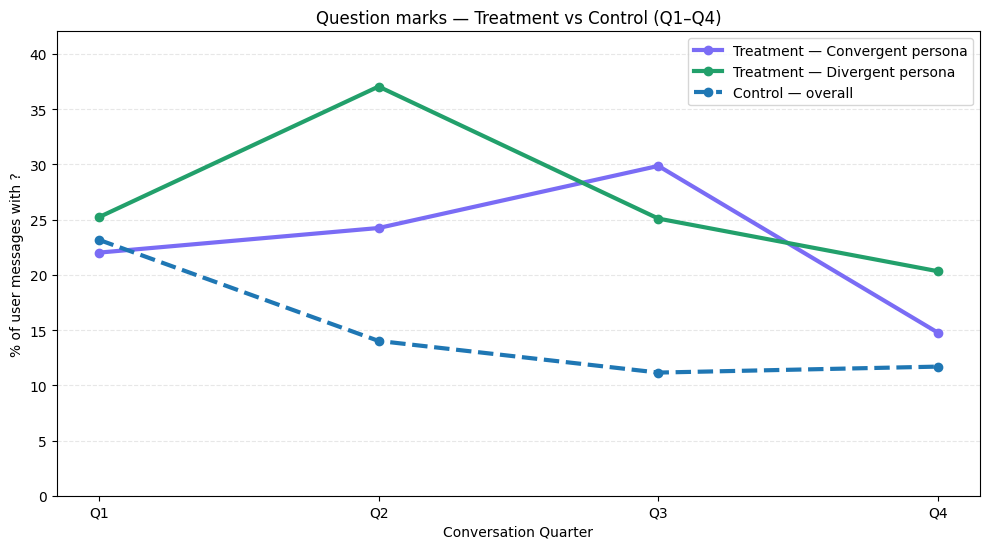


Saved: figure12a_question_marks.png and figure12a_question_marks.pdf


In [ ]:
# --- Curiosity (question marks) analysis & Figure 12a: Colab-ready script ---

!pip -q install pandas scipy openpyxl matplotlib

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load raw messages
# -----------------------------
MSGS_PATH = "messages1307_quartered.xlsx"   # <- change if needed
msgs = pd.read_excel(MSGS_PATH, sheet_name=0)
msgs.columns = [c.strip() for c in msgs.columns]
msgs = msgs.sort_values(["conversation_id", "pos"]).reset_index(drop=True)

# -----------------------------
# 2) Normalize group labels
# -----------------------------
def norm_group(s):
    s = str(s).lower()
    if "experiment" in s or "exp" in s: return "Experiment"
    if "control" in s or "ctrl" in s:   return "Control"
    return s
msgs["group_clean"] = msgs["group typer"].apply(norm_group)

# -----------------------------
# 3) For each USER message, infer which persona it addressed:
#    look ahead to the next assistant message (Alex->Convergent; Taylor->Divergent)
# -----------------------------
def assign_targets(df_one_conv: pd.DataFrame) -> pd.DataFrame:
    df = df_one_conv.copy().reset_index(drop=True)
    target = [None] * len(df)
    for i in range(len(df)-1):
        if df.loc[i, "message source"] == "user":
            j = i + 1
            while j < len(df) and df.loc[j, "message source"] == "user":
                j += 1
            if j < len(df) and df.loc[j, "message source"] in ("Alex", "Taylor"):
                target[i] = "Convergent persona" if df.loc[j, "message source"] == "Alex" else "Divergent persona"
    df["target_persona"] = target
    return df

msgs = msgs.groupby("conversation_id", group_keys=False).apply(assign_targets)

# -----------------------------
# 4) Keep Q1–Q4 and build curiosity features per user message
# -----------------------------
mid = msgs[msgs["quarter"].isin(["Q1","Q2","Q3","Q4"])].copy() # Modified to include Q1
um  = mid[(mid["message source"]=="user") & (mid["target_persona"].notna())].copy()

# primary metric: number of "?" in a message; secondary: any question?
um["q_count"] = um["message"].astype(str).str.count(r"\?")
um["is_q"]    = um["q_count"] > 0

# -----------------------------
# 5) Aggregate per conversation × quarter × persona
# -----------------------------
agg = (um.groupby(["group_clean","conversation_id","quarter","target_persona"])
         .agg(n_user=("message_id","count"),
              n_q=("is_q","sum"),
              sum_q=("q_count","sum"))
         .reset_index())

# Metrics:
# - q_per_msg: average number of "?" per user message (primary)
# - pct_q: percentage of user messages containing at least one "?"
agg["q_per_msg"] = np.where(agg["n_user"]>0, agg["sum_q"]/agg["n_user"], np.nan)
agg["pct_q"]     = np.where(agg["n_user"]>0, agg["n_q"]/agg["n_user"], np.nan)

# -----------------------------
# 6) Welch t-tests (as reported)
#    Compare Experiment vs Control (overall) for each persona on primary + secondary metrics
# -----------------------------
def welch(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if len(a)<2 or len(b)<2:
        return np.nan, np.nan, len(a), len(b)
    t = stats.ttest_ind(a, b, equal_var=False)
    return t.statistic, t.pvalue, len(a), len(b)

# Build per-conversation metrics by collapsing across quarters
perconv = (agg.groupby(["group_clean","conversation_id","target_persona"])
             .agg(q_per_msg=("q_per_msg","mean"),
                  pct_q=("pct_q","mean"))
             .reset_index())

# Experiment vs Control (overall baseline) — Divergent
t_div_qpm, p_div_qpm, nE_div, nC_div = welch(perconv.query("group_clean=='Experiment' and target_persona=='Divergent persona'")["q_per_msg"],
                                              perconv.query("group_clean=='Control'")["q_per_msg"])
t_div_pct, p_div_pct, _, _ = welch(perconv.query("group_clean=='Experiment' and target_persona=='Divergent persona'")["pct_q"],
                                   perconv.query("group_clean=='Control'")["pct_q"])

# Experiment vs Control (overall baseline) — Convergent
t_con_qpm, p_con_qpm, nE_con, nC_con = welch(perconv.query("group_clean=='Experiment' and target_persona=='Convergent persona'")["q_per_msg"],
                                              perconv.query("group_clean=='Control'")["q_per_msg"])
t_con_pct, p_con_pct, _, _ = welch(perconv.query("group_clean=='Experiment' and target_persona=='Convergent persona'")["pct_q"],
                                   perconv.query("group_clean=='Control'")["pct_q"])

print("Welch tests, Experiment vs Control (overall baseline):")
print(f"  Divergent persona — avg '?' per msg: t={t_div_qpm:.2f}, p={p_div_qpm:.3f}, n_E={nE_div}, n_C={nC_con}") # Corrected n_C
print(f"  Divergent persona — % msg with '?':  t={t_div_pct:.2f}, p={p_div_pct:.3f}")
print(f"  Convergent persona — avg '?' per msg: t={t_con_qpm:.2f}, p={p_con_qpm:.3f}, n_E={nE_con}, n_C={nC_con}")
print(f"  Convergent persona — % msg with '?':  t={t_con_pct:.2f}, p={p_con_pct:.3f}")


# -----------------------------
# 7) Figure 12a: Question marks — Experiment vs Control (Q1–Q4) # Modified title
#     - Experiment: two lines (Convergent persona, Divergent persona)
#     - Control: single overall line (averaged across personas)
# -----------------------------
q_order = ["Q1","Q2","Q3","Q4"] # Modified to include Q1

exp_conv = (agg[(agg["group_clean"]=="Experiment") & (agg["target_persona"]=="Convergent persona")]
              .groupby("quarter")["pct_q"].mean().reindex(q_order))*100
exp_div  = (agg[(agg["group_clean"]=="Experiment") & (agg["target_persona"]=="Divergent persona")]
              .groupby("quarter")["pct_q"].mean().reindex(q_order))*100
ctrl_all = (agg[agg["group_clean"]=="Control"]
              .groupby("quarter")["pct_q"].mean().reindex(q_order))*100

plt.figure(figsize=(10,5.6))
plt.plot(q_order, exp_conv.values, marker="o", linewidth=3, label="Treatment — Convergent persona", color="#7A6CF5") # Changed color
plt.plot(q_order, exp_div.values,  marker="o", linewidth=3, label="Treatment — Divergent persona", color="#22A06B") # Changed color
plt.plot(q_order, ctrl_all.values, marker="o", linewidth=3, linestyle="--", label="Control — overall") # Changed color

plt.xlabel("Conversation Quarter")
plt.ylabel("% of user messages with ?")
plt.title("Question marks — Treatment vs Control (Q1–Q4)") # Modified title
plt.legend()
ymax = float(np.nanmax([exp_conv.max(), exp_div.max(), ctrl_all.max()]))
plt.ylim(0, max(40, ymax+5))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

# Save outputs
plt.savefig("figure12a_question_marks.png", dpi=300)
plt.savefig("figure12a_question_marks.pdf")
plt.show()

print("\nSaved: figure12a_question_marks.png and figure12a_question_marks.pdf")

# Idea originality and traits


Group contrasts on originality (Welch tests)
                 metric                              label  n1  n0       m1       m0   t_stat        p
inter_mean_to_samegroup                     Same condition  70  31 0.341415 0.282192 5.128104 0.000002
      inter_mean_to_all                   All participants  70  31 0.334010 0.306926 2.344773 0.021503
inter_min_to_othergroup Cross-condition nearest (distance)  70  31 0.204747 0.166630 3.122177 0.002490

Saving single summary figure
[saved] /content/out/fig_single_originality_summary.png

Merging questionnaire and exploring associations
Ownership (1-5): Exp 3.56, Ctrl 4.07, Welch p = 0.0185 (n_e=66, n_c=29)
Taylor helped me arrive at a creative solution: Exp 3.89, Ctrl 3.41, Welch p = 0.0565
My creativity increased after Taylor: Exp 3.65, Ctrl 2.76, Welch p = 0.0034
Experiment: persona_helped vs inter_mean_to_samegroup -> rho=0.222, p=0.0732, n=66
Experiment: persona_helped vs inter_min_to_othergroup -> rho=0.226, p=0.0678, n=66
Experi

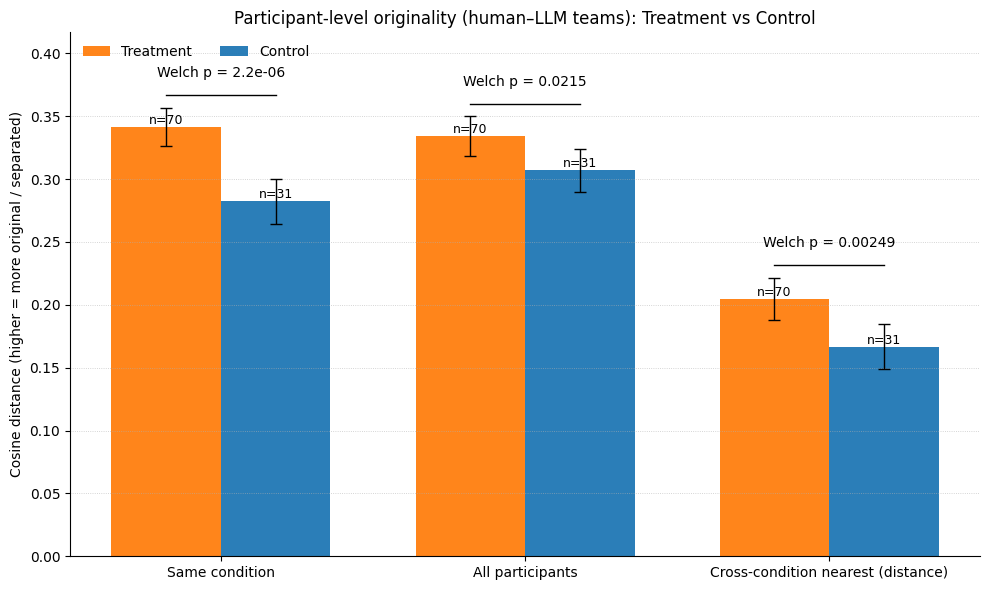

In [ ]:
# colab_validation_analysis.py
# Google Colab-ready script to validate participant-level originality results
# and explore relationships with post-session questionnaires.

import os
import math
# import argparse # Removed argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Config
# -----------------------------
DEFAULT_PARTICIPANTS_CSV = "/content/participants_metrics.csv" # Updated path
DEFAULT_SUMMARY_CSV      = "/content/out/group_comparison_summary.csv"  # optional, Updated path
DEFAULT_SURVEY_XLSX      = "Responses 13 07 (1).xlsx"  # questionnaire
#DEFAULT_SURVEY_XLSX      = "/content/content/curiosity_vs_questionnaire_8items (1).xlsx"  # questionnaire
OUT_DIR                  = "/content/out"


# -----------------------------
# Utilities
# -----------------------------
def ensure_outdir(path: str):
    Path(path).mkdir(parents=True, exist_ok=True)

def welch_t(a, b):
    """Return Welch t-test p-value, along with sample means and sizes."""
    a = pd.Series(a).dropna().values
    b = pd.Series(b).dropna().values
    t = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return {
        "n1": int(a.size), "n0": int(b.size),
        "m1": float(a.mean()) if a.size else float("nan"),
        "m0": float(b.mean()) if b.size else float("nan"),
        "p": float(t.pvalue) if np.isfinite(t.pvalue) else float("nan"),
        "t_stat": float(t.statistic) if np.isfinite(t.statistic) else float("nan")
    }

def mean_ci95(x):
    """Return mean and t-based 95% CI around the mean."""
    x = pd.Series(x).dropna().values
    n = x.size
    if n == 0:
        return float("nan"), float("nan"), float("nan"), n
    m = float(x.mean())
    if n == 1:
        return m, float("nan"), float("nan"), n
    sd = float(x.std(ddof=1))
    se = sd / math.sqrt(n)
    tcrit = stats.t.ppf(0.975, n-1)
    return m, m - tcrit*se, m + tcrit*se, n

def spearman(x, y):
    """Spearman rho and p-value with nan handling."""
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 10:
        return float("nan"), float("nan"), int(mask.sum())
    rho, p = stats.spearmanr(x[mask], y[mask])
    return float(rho), float(p), int(mask.sum())

def print_header(s):
    print("\n" + "="*len(s))
    print(s)
    print("="*len(s))


# -----------------------------
# Core analysis
# -----------------------------
PRIMARY_METRICS = [
    ("inter_mean_to_samegroup", "Same condition"),
    ("inter_mean_to_all",       "All participants"),
    ("inter_min_to_othergroup", "Cross-condition nearest (distance)"),
]

LIKERT_VARS = [
    "alex_interface_rating",
    "taylor_interface_rating",
    "creativity_increase_alex",
    "creativity_increase_taylor",
    "solution_ownership",
    "interface_comparison",
    "ai_tool_mastery",
    "persona_helped"
]

BIG5_VARS = [
    "Extraversion", "Agreeableness", "Conscientiousness",
    "Negative Emotionality", "Open-Mindedness"
]

def load_participants(path):
    df = pd.read_csv(path)
    # Normalize group labels
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip().str.lower()
    return df

def load_survey(path):
    # We expect a "Merged" sheet with questionnaire items
    xl = pd.ExcelFile(path)
    sheet = "Merged" if "Merged" in xl.sheet_names else xl.sheet_names[0]
    q = xl.parse(sheet)
    # Keep only columns we need (if present)
    keep = ["conversation_id","Group type"] + LIKERT_VARS + BIG5_VARS
    keep = [c for c in keep if c in q.columns]
    q = q[keep].copy()
    # Normalize group label for join symmetry
    if "Group type" in q.columns:
        q["Group type"] = q["Group type"].astype(str).str.strip().str.lower()
    return q

def group_ttests(part, out_dir):
    """Replicate the core Welch comparisons for the primary metrics."""
    rows = []
    for metric, label in PRIMARY_METRICS:
        a = part.loc[part["group"]=="experiment group", metric]
        b = part.loc[part["group"]=="control group", metric]
        res = welch_t(a, b); res["metric"] = metric; res["label"] = label
        rows.append(res)
    tab = pd.DataFrame(rows)[["metric","label","n1","n0","m1","m0","t_stat","p"]]
    tab.to_csv(Path(out_dir)/"validation_group_ttests.csv", index=False)
    return tab

def merge_participants_survey(part, survey):
    # Merge on conversation_id
    if "Group type" in survey.columns:
        survey = survey.rename(columns={"Group type": "group_survey"})
    df = part.merge(survey, on="conversation_id", how="left")
    return df

def correlation_sweeps(df, out_dir):
    """Compute Spearman correlations of originality with questionnaire items, overall and by group."""
    rows_all, rows_by = [], []
    for metric, _label in PRIMARY_METRICS:
        for qcol in LIKERT_VARS:
            if qcol not in df.columns: continue
            rho, p, n = spearman(df[metric], df[qcol])
            rows_all.append({"metric": metric, "question": qcol, "n": n, "rho": rho, "p": p})

        # Big Five
        for b in BIG5_VARS:
            if b not in df.columns: continue
            rho, p, n = spearman(df[metric], df[b])
            rows_all.append({"metric": metric, "question": b, "n": n, "rho": rho, "p": p})

    all_tab = pd.DataFrame(rows_all).sort_values("p")
    all_tab.to_csv(Path(out_dir)/"validation_correlations_overall.csv", index=False)

    # by-group
    rows = []
    for g in ["experiment group","control group"]:
        sub = df[df["group"]==g]
        for metric, _label in PRIMARY_METRICS:
            for qcol in LIKERT_VARS + BIG5_VARS:
                if qcol not in df.columns: continue
                rho, p, n = spearman(sub[metric], sub[qcol])
                rows.append({"group": g, "metric": metric, "question": qcol, "n": n, "rho": rho, "p": p})
    by_tab = pd.DataFrame(rows).sort_values(["group","p"])
    by_tab.to_csv(Path(out_dir)/"validation_correlations_bygroup.csv", index=False)
    return all_tab, by_tab

def single_summary_figure(part, out_dir):
    """Single figure with three grouped outcomes, Control=blue, Experiment=orange."""
    color_ctrl = "#1f77b4"   # blue
    color_exp  = "#ff7f0e"   # orange

    rows = []
    for metric, label in PRIMARY_METRICS:
        c = part[part["group"]=="control group"][metric].dropna()
        e = part[part["group"]=="experiment group"][metric].dropna()
        m_c, lo_c, hi_c, n_c = mean_ci95(c)
        m_e, lo_e, hi_e, n_e = mean_ci95(e)
        rows.append((label, metric, m_c, lo_c, hi_c, n_c, m_e, lo_e, hi_e, n_e))

    # Gather Welch p-values for annotations using fresh computation
    pvals = {}
    for label, metric in [(r[0], r[1]) for r in rows]:
        res = welch_t(part[part["group"]=="experiment group"][metric],
                      part[part["group"]=="control group"][metric])
        pvals[label] = res["p"]

    # Plot
    plt.figure(figsize=(10, 6))
    x = np.arange(len(rows))
    width = 0.36

    for i, (label, metric, m_c, lo_c, hi_c, n_c, m_e, lo_e, hi_e, n_e) in enumerate(rows):
        # Experiment (left bar)
        plt.bar(x[i]-width/2, m_e, width, color=color_exp, alpha=0.95, label="Treatment" if i==0 else "")
        if np.isfinite(lo_e) and np.isfinite(hi_e):
            plt.errorbar(x[i]-width/2, m_e, yerr=[[m_e-lo_e],[hi_e-m_e]], fmt='none', ecolor="black", capsize=4, lw=1)

        # Control (right bar)
        plt.bar(x[i]+width/2, m_c, width, color=color_ctrl, alpha=0.95, label="Control" if i==0 else "")
        if np.isfinite(lo_c) and np.isfinite(hi_c):
             plt.errorbar(x[i]+width/2, m_c, yerr=[[m_c-lo_c],[hi_c-m_c]], fmt='none', ecolor="black", capsize=4, lw=1)

        # Ns and p-value annotation
        plt.text(x[i]-width/2, m_e, f"n={n_e}", ha="center", va="bottom", fontsize=9)
        plt.text(x[i]+width/2, m_c, f"n={n_c}", ha="center", va="bottom", fontsize=9)

        y_top = max(hi_c if np.isfinite(hi_c) else m_c, hi_e if np.isfinite(hi_e) else m_e)
        y_line = y_top + 0.01
        plt.plot([x[i]-width/2, x[i]+width/2], [y_line, y_line], color="black", lw=1)
        plt.text(x[i], y_line + 0.012, f"Welch p = {pvals[label]:.3g}", ha="center", va="bottom", fontsize=10)

    plt.xticks(x, [r[0] for r in rows])
    plt.ylabel("Cosine distance (higher = more original / separated)")
    plt.title("Participant-level originality (human–LLM teams): Treatment vs Control")
    plt.legend(frameon=False, ncol=2, loc="upper left")
    plt.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
    for spine in ["top","right"]:
        plt.gca().spines[spine].set_visible(False)
    ymax = max([max(r[4] if np.isfinite(r[4]) else r[2], r[8] if np.isfinite(r[8]) else r[6]) for r in rows]) + 0.06
    plt.ylim(0, ymax)
    plt.tight_layout()
    fig_path = Path(out_dir) / "fig_single_originality_summary.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"[saved] {fig_path}")


def key_replications(df):
    """Replicate key relationships used in the narrative."""
    # 1) Ownership difference
    e_own = df[df["group"]=="experiment group"]["solution_ownership"]
    c_own = df[df["group"]=="control group"]["solution_ownership"]
    r = welch_t(e_own, c_own)
    print(f"Ownership (1-5): Exp {r['m1']:.2f}, Ctrl {r['m0']:.2f}, Welch p = {r['p']:.4f} (n_e={r['n1']}, n_c={r['n0']})")

    # 2) Taylor creativity ratings by group
    for col, label in [("taylor_interface_rating","Taylor helped me arrive at a creative solution"),
                       ("creativity_increase_taylor","My creativity increased after Taylor")]:
        e = df[df["group"]=="experiment group"][col]
        c = df[df["group"]=="control group"][col]
        r = welch_t(e, c)
        print(f"{label}: Exp {r['m1']:.2f}, Ctrl {r['m0']:.2f}, Welch p = {r['p']:.4f}")

    # 3) Correlations in persona group: persona preference vs originality and idea count
    dfe = df[df["group"]=="experiment group"]
    if "persona_helped" in dfe.columns:
        for ycol in ["inter_mean_to_samegroup","inter_min_to_othergroup","inter_mean_to_all","n_ideas"]:
            if ycol not in dfe.columns: continue
            rho, p, n = spearman(dfe["persona_helped"], dfe[ycol])
            print(f"Experiment: persona_helped vs {ycol} -> rho={rho:.3f}, p={p:.4f}, n={n}")

    # 4) Overall originality vs Taylor creativity increase (weak overall correlation)
    if "creativity_increase_taylor" in df.columns:
        rho, p, n = spearman(df["inter_mean_to_samegroup"], df["creativity_increase_taylor"])
        print(f"All: originality(same-group) vs creativity_increase_taylor -> rho={rho:.3f}, p={rho:.4f}, n={n}")

    # 5) Control-only: originality vs creativity_increase_alex (negative)
    dfc = df[df["group"]=="control group"]
    if "creativity_increase_alex" in dfc.columns:
        rho, p, n = spearman(dfc["inter_mean_to_samegroup"], dfc["creativity_increase_alex"])
        print(f"Control: originality(same-group) vs creativity_increase_alex -> rho={rho:.3f}, p={rho:.4f}, n={n}")


# -----------------------------
# Main
# -----------------------------
# def main(args=None): # Removed args
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--participants_csv", type=str, default=DEFAULT_PARTICIPANTS_CSV)
#     parser.add_argument("--summary_csv", type=str, default=DEFAULT_SUMMARY_CSV)
#     parser.add_argument("--survey_xlsx", type=str, default=DEFAULT_SURVEY_XLSX)
#     parser.add_argument("--outdir", type=str, default=OUT_DIR)
#     cfg = parser.parse_args(args=args) # Removed args

ensure_outdir(OUT_DIR) # Directly use OUT_DIR

# Load participants-level metrics
part = load_participants(DEFAULT_PARTICIPANTS_CSV) # Directly use default path
if not set(["group","conversation_id"]).issubset(part.columns):
    raise ValueError("participants_metrics.csv must include 'group' and 'conversation_id'.")

print_header("Group contrasts on originality (Welch tests)")
ttab = group_ttests(part, OUT_DIR) # Directly use OUT_DIR
print(ttab.to_string(index=False))

# Single figure
print_header("Saving single summary figure")
single_summary_figure(part, OUT_DIR) # Directly use OUT_DIR

# If survey is present, merge and explore relationships
if Path(DEFAULT_SURVEY_XLSX).exists(): # Directly use default path
    print_header("Merging questionnaire and exploring associations")
    survey = load_survey(DEFAULT_SURVEY_XLSX) # Directly use default path
    df = merge_participants_survey(part, survey)
    all_tab, by_tab = correlation_sweeps(df, OUT_DIR) # Directly use OUT_DIR
    key_replications(df)

    print("\nTop overall correlations (first 12):")
    print(all_tab.head(12).to_string(index=False))

    print("\nTop by-group correlations (first 12 per group):")
    for g in ["experiment group","control group"]:
        sub = by_tab[by_tab["group"]==g].head(12)
        print(f"\n{g}:")
        print(sub.to_string(index=False))
else:
    print_header("Questionnaire file not found, skipping correlation analyses")

print(f"\nAll outputs saved under: {OUT_DIR}")

# if __name__ == "__main__": # Removed main block
#     main()